# Spectral Analysis — Consolidated Results (L-SML, Paper-Aligned)

**Step 106 notebook.** Re-runs all Consolidated Results fusion using the
pure unsupervised binary L-SML pipeline of Parisi-Nadler-Kluger [PNAS 2014]
and Jaffé-Fetaya-Nadler [2016].

**What's different from the original `Spectral_Analysis_Consolidated_Results.ipynb`:**

| Aspect | Old (`best_nadler_on`) | New (`sml_unsupervised`) |
|---|---|---|
| Inputs | continuous z-scored | **binary ±1** (median-binarized) |
| Sign orientation | from labels (`boot_auc`) | **eigenvector sign + assumption (iii)** |
| Subset selection | exhaustive search using labels | **no subset — use all 16 features** |
| Correlated features | Spearman ρ filter | **L-SML group detection (Paper 1)** |
| Supervision | Val labels for sign + subset | **None — fully unsupervised** |
| Labels used for | sign + subset + AUROC | **AUROC only (reporting)** |

**Re-uses cached features** from the original notebook's pkl files in
`consolidated_results/` — no GPU inference needed. CPU only, ~10–30 min total.

**Outputs (separate from Step 100 results):**
- `consolidated_results/lsml_<domain>_res.pkl` per domain
- `consolidated_results/lsml_results_all.pkl` combined
- `consolidated_results/lsml_summary.csv` comparison table


## Section 1 — Setup

In [1]:
import os, sys, shutil
os.environ['PYTHONIOENCODING'] = 'utf-8'

REPO_DIR = '/content/hallucination_detection'

# Pull the feature/nadler-paper-alignment branch which contains sml_unsupervised
if os.path.exists(REPO_DIR) and not os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')):
    shutil.rmtree(REPO_DIR)

if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b feature/nadler-paper-alignment '
              f'https://github.com/omrisegev/hallucination_detection.git {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} fetch --all -q')
    os.system(f'git -C {REPO_DIR} checkout feature/nadler-paper-alignment -q')
    os.system(f'git -C {REPO_DIR} pull -q')

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Confirm the new functions are available
from spectral_utils import (
    sml_unsupervised, sml_unsupervised_compare,
    detect_dependent_groups, lsml_fuse,
    binarize_classifiers, sml_fuse_signed,
    boot_auc, FEAT_NAMES,
    extract_all_features, sw_var_peak_adaptive,
)
print('spectral_utils imported OK')
print('L-SML functions:', [
    'sml_unsupervised', 'sml_unsupervised_compare',
    'detect_dependent_groups', 'lsml_fuse',
])
print(f'FEAT_NAMES ({len(FEAT_NAMES)}):', FEAT_NAMES)


spectral_utils imported OK
L-SML functions: ['sml_unsupervised', 'sml_unsupervised_compare', 'detect_dependent_groups', 'lsml_fuse']
FEAT_NAMES (16): ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power', 'hl_ratio', 'dominant_freq', 'spectral_centroid', 'stft_max_high_power', 'stft_spectral_entropy', 'rpdi', 'sw_var_peak', 'pe_mean', 'hurst_exponent', 'cusum_max', 'cusum_shift_idx']


In [2]:
# Mount Drive + paths
from google.colab import drive
drive.mount('/content/drive')

import pickle, json, time
import numpy as np

BASE     = '/content/drive/MyDrive'
HALL_DIR = f'{BASE}/hallucination_detection'
OUT_DIR  = f'{HALL_DIR}/consolidated_results'
PLOT_DIR = f'{OUT_DIR}/plots'
LSML_PLOT_DIR = f'{PLOT_DIR}/lsml'
os.makedirs(LSML_PLOT_DIR, exist_ok=True)

print(f'OUT_DIR = {OUT_DIR}  (exists: {os.path.exists(OUT_DIR)})')

# Cached feature pkls produced by the original Consolidated notebook
CACHED_FEAT_PKLS = {
    'math500': os.path.join(OUT_DIR, 'math500_res.pkl'),  # {'results': ..., 'feats': {key: (fd, lbl)}}
    'gsm8k':   os.path.join(OUT_DIR, 'gsm8k_res.pkl'),
    'gpqa':    os.path.join(OUT_DIR, 'gpqa_res.pkl'),
    'rag':     os.path.join(OUT_DIR, 'rag_feats_all.pkl'),  # {key: (fd, lbl)} (no 'results' wrapper)
    'qa':      os.path.join(OUT_DIR, 'qa_res.pkl'),
}

for name, p in CACHED_FEAT_PKLS.items():
    status = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'  [{status}] {name}: {p}')


Mounted at /content/drive
OUT_DIR = /content/drive/MyDrive/hallucination_detection/consolidated_results  (exists: True)
  [OK] math500: /content/drive/MyDrive/hallucination_detection/consolidated_results/math500_res.pkl
  [OK] gsm8k: /content/drive/MyDrive/hallucination_detection/consolidated_results/gsm8k_res.pkl
  [OK] gpqa: /content/drive/MyDrive/hallucination_detection/consolidated_results/gpqa_res.pkl
  [OK] rag: /content/drive/MyDrive/hallucination_detection/consolidated_results/rag_feats_all.pkl
  [OK] qa: /content/drive/MyDrive/hallucination_detection/consolidated_results/qa_res.pkl


In [3]:
# L-SML helper — runs sml_unsupervised with both K-selection methods
def run_lsml(fd, lbl, key_str, K_range=range(2, 7), verbose=True):
    """
    Run unsupervised binary L-SML with both K-selection methods.

    Returns a dict with both methods' AUROCs and group structure.
    Labels are used ONLY for the final AUROC computation (no leakage into fusion).
    """
    lbl = np.asarray(lbl, dtype=int)
    if len(set(lbl.tolist())) < 2:
        if verbose: print(f'  [{key_str}] only one class — skip')
        return None
    n_pos = int(lbl.sum()); n_neg = int(len(lbl) - n_pos)

    # Individual feature AUCs (unchanged — these don't use fusion)
    from sklearn.metrics import roc_auc_score
    ind_aucs = {}
    for fn in FEAT_NAMES:
        try:
            a = roc_auc_score(lbl, fd[fn])
            ind_aucs[fn] = max(a, 1 - a)
        except Exception:
            ind_aucs[fn] = 0.5

    try:
        cmp = sml_unsupervised_compare(fd, FEAT_NAMES, K_range=K_range, labels=lbl)
    except Exception as e:
        if verbose: print(f'  [{key_str}] L-SML error: {e}')
        return None

    r_meta = cmp['residual_meta']
    e_meta = cmp['eigengap_meta']
    res_fused = cmp['residual_fused']
    eig_fused = cmp['eigengap_fused']

    # Bootstrap CI for residual (paper-faithful) headline AUROC
    p_auc, p_lo, p_hi = boot_auc(lbl, res_fused)
    n_auc, n_lo, n_hi = boot_auc(lbl, -res_fused)
    if p_auc >= n_auc:
        r_auc, r_lo, r_hi = p_auc, p_lo, p_hi
    else:
        r_auc, r_lo, r_hi = n_auc, n_lo, n_hi

    p_auc, p_lo, p_hi = boot_auc(lbl, eig_fused)
    n_auc, n_lo, n_hi = boot_auc(lbl, -eig_fused)
    if p_auc >= n_auc:
        e_auc, e_lo, e_hi = p_auc, p_lo, p_hi
    else:
        e_auc, e_lo, e_hi = n_auc, n_lo, n_hi

    if verbose:
        print(f'  [{key_str}] N={len(lbl)} (+{n_pos}/-{n_neg}) | '
              f'L-SML(resid)={r_auc:.3f} [{r_lo:.3f},{r_hi:.3f}] K={r_meta["K"]} | '
              f'(eig)={e_auc:.3f} K={e_meta["K"]} | ARI={cmp["group_ARI"]:.2f}')

    return {
        'n': len(lbl), 'n_pos': n_pos, 'n_neg': n_neg,
        'ind_aucs': ind_aucs,

        # Headline (paper-faithful Algorithm 1 residual K-selection)
        'lsml_residual_auc': r_auc, 'lsml_residual_lo': r_lo, 'lsml_residual_hi': r_hi,
        'lsml_residual_K': r_meta['K'],
        'lsml_residual_c': r_meta['c'].tolist(),
        'lsml_residual_groups': [
            (idx.tolist(), w.tolist()) for idx, w in r_meta['group_weights']
        ],
        'lsml_residual_cross_w': r_meta['cross_weights'].tolist(),
        'lsml_residual_method_resid': float(r_meta['residual']),

        # Alternative (eigengap heuristic)
        'lsml_eigengap_auc': e_auc, 'lsml_eigengap_lo': e_lo, 'lsml_eigengap_hi': e_hi,
        'lsml_eigengap_K': e_meta['K'],
        'lsml_eigengap_c': e_meta['c'].tolist(),

        # Agreement diagnostics
        'group_ARI': cmp['group_ARI'], 'same_K': bool(cmp['same_K']),
    }


# Helper to load cached (feats_dict, labels) from various pkl formats
def load_cached_feats(pkl_path):
    """
    Load cached features. Handles two formats:
      1. {'results': RES, 'feats': FEATS} where FEATS = {key: (fd, lbl)}
      2. {key: (fd, lbl)} directly (e.g. rag_feats_all.pkl)
    Returns dict {key: (fd, lbl)} or None if file missing/invalid.
    """
    if not os.path.exists(pkl_path):
        return None
    with open(pkl_path, 'rb') as f:
        obj = pickle.load(f)
    if isinstance(obj, dict) and 'feats' in obj:
        return obj['feats']
    return obj


print('Helpers defined.')


Helpers defined.


## Section 2 — MATH-500 (Phases 4/5)

In [4]:
LSML_PATH = os.path.join(OUT_DIR, 'lsml_math500_res.pkl')
FORCE = False

MATH500_FEATS = load_cached_feats(CACHED_FEAT_PKLS['math500'])
if MATH500_FEATS is None:
    print('ERROR: math500_res.pkl not found. Run Spectral_Analysis_Consolidated_Results.ipynb first.')
    MATH500_LSML = {}
elif not FORCE and os.path.exists(LSML_PATH):
    with open(LSML_PATH, 'rb') as f: MATH500_LSML = pickle.load(f)
    print(f'Loaded cached MATH500 L-SML ({len(MATH500_LSML)} keys)')
else:
    print(f'Running L-SML on MATH-500 ({len(MATH500_FEATS)} keys)...')
    MATH500_LSML = {}
    for key, (fd, lbl) in MATH500_FEATS.items():
        MATH500_LSML[key] = run_lsml(fd, lbl, f'MATH500/{key}')
        with open(LSML_PATH, 'wb') as f: pickle.dump(MATH500_LSML, f)
    print(f'Saved {LSML_PATH}')


Running L-SML on MATH-500 (4 keys)...
  [MATH500/Qwen2.5-Math-1.5B-Instruct_T1.0] N=300 (+133/-167) | L-SML(resid)=0.821 [0.767,0.868] K=6 | (eig)=0.772 K=2 | ARI=0.09
  [MATH500/Qwen-Math-7B_T1.0] N=300 (+84/-216) | L-SML(resid)=0.912 [0.860,0.952] K=5 | (eig)=0.892 K=2 | ARI=0.17
  [MATH500/deepseek-math-7b-instruct_T1.0] N=300 (+59/-241) | L-SML(resid)=0.649 [0.574,0.722] K=5 | (eig)=0.539 K=2 | ARI=0.10
  [MATH500/DeepSeek-R1-Distill-Llama-8B_T1.0] N=300 (+123/-177) | L-SML(resid)=0.789 [0.735,0.843] K=6 | (eig)=0.773 K=2 | ARI=0.12
Saved /content/drive/MyDrive/hallucination_detection/consolidated_results/lsml_math500_res.pkl


## Section 3 — GSM8K (Phase 7)

In [5]:
LSML_PATH = os.path.join(OUT_DIR, 'lsml_gsm8k_res.pkl')
FORCE = False

GSM8K_FEATS = load_cached_feats(CACHED_FEAT_PKLS['gsm8k'])
if GSM8K_FEATS is None:
    print('ERROR: gsm8k_res.pkl not found.')
    GSM8K_LSML = {}
elif not FORCE and os.path.exists(LSML_PATH):
    with open(LSML_PATH, 'rb') as f: GSM8K_LSML = pickle.load(f)
    print(f'Loaded cached GSM8K L-SML ({len(GSM8K_LSML)} keys)')
else:
    print(f'Running L-SML on GSM8K ({len(GSM8K_FEATS)} keys)...')
    GSM8K_LSML = {}
    for key, (fd, lbl) in GSM8K_FEATS.items():
        GSM8K_LSML[key] = run_lsml(fd, lbl, f'GSM8K/{key}')
        with open(LSML_PATH, 'wb') as f: pickle.dump(GSM8K_LSML, f)
    print(f'Saved {LSML_PATH}')


Running L-SML on GSM8K (1 keys)...
  [GSM8K/Llama-8B_T1.0] N=1319 (+1043/-276) | L-SML(resid)=0.704 [0.669,0.740] K=4 | (eig)=0.565 K=2 | ARI=0.45
Saved /content/drive/MyDrive/hallucination_detection/consolidated_results/lsml_gsm8k_res.pkl


## Section 4 — GPQA Diamond (Phases 4/5/8)

In [6]:
LSML_PATH = os.path.join(OUT_DIR, 'lsml_gpqa_res.pkl')
FORCE = False

GPQA_FEATS = load_cached_feats(CACHED_FEAT_PKLS['gpqa'])
if GPQA_FEATS is None:
    print('ERROR: gpqa_res.pkl not found.')
    GPQA_LSML = {}
elif not FORCE and os.path.exists(LSML_PATH):
    with open(LSML_PATH, 'rb') as f: GPQA_LSML = pickle.load(f)
    print(f'Loaded cached GPQA L-SML ({len(GPQA_LSML)} keys)')
else:
    print(f'Running L-SML on GPQA ({len(GPQA_FEATS)} keys)...')
    GPQA_LSML = {}
    for key, (fd, lbl) in GPQA_FEATS.items():
        GPQA_LSML[key] = run_lsml(fd, lbl, f'GPQA/{key}')
        with open(LSML_PATH, 'wb') as f: pickle.dump(GPQA_LSML, f)
    print(f'Saved {LSML_PATH}')


Running L-SML on GPQA (5 keys)...
  [GPQA/Llama-8B_T1.0] N=198 (+53/-145) | L-SML(resid)=0.521 [0.420,0.620] K=5 | (eig)=0.509 K=2 | ARI=0.35
  [GPQA/Qwen-7B_T1.0] N=198 (+60/-138) | L-SML(resid)=0.585 [0.505,0.666] K=4 | (eig)=0.571 K=2 | ARI=0.16
  [GPQA/DeepSeek-R1-Distill-Llama-8B_T1.0] N=198 (+48/-150) | L-SML(resid)=0.558 [0.464,0.649] K=3 | (eig)=0.524 K=2 | ARI=0.37
  [GPQA/Mistral-7B_T1.0] N=198 (+50/-148) | L-SML(resid)=0.568 [0.471,0.664] K=6 | (eig)=0.573 K=2 | ARI=0.20
  [GPQA/Qwen2.5-72B-Instruct-AWQ_T1.0] N=198 (+80/-118) | L-SML(resid)=0.624 [0.546,0.704] K=4 | (eig)=0.529 K=2 | ARI=0.32
Saved /content/drive/MyDrive/hallucination_detection/consolidated_results/lsml_gpqa_res.pkl


## Section 5 — RAG L-CiteEval (Phase 10)

In [7]:
LSML_PATH = os.path.join(OUT_DIR, 'lsml_rag_res.pkl')
FORCE = False

RAG_FEATS = load_cached_feats(CACHED_FEAT_PKLS['rag'])
if RAG_FEATS is None:
    print('ERROR: rag_feats_all.pkl not found.')
    RAG_LSML = {}
elif not FORCE and os.path.exists(LSML_PATH):
    with open(LSML_PATH, 'rb') as f: RAG_LSML = pickle.load(f)
    print(f'Loaded cached RAG L-SML ({len(RAG_LSML)} keys)')
else:
    print(f'Running L-SML on RAG ({len(RAG_FEATS)} keys)...')
    RAG_LSML = {}
    for key, (fd, lbl) in RAG_FEATS.items():
        RAG_LSML[key] = run_lsml(fd, lbl, f'RAG/{key}')
        with open(LSML_PATH, 'wb') as f: pickle.dump(RAG_LSML, f)
    print(f'Saved {LSML_PATH}')


Running L-SML on RAG (16 keys)...
  [RAG/Qwen-7B/hotpotqa] N=169 (+15/-154) | L-SML(resid)=0.565 [0.432,0.696] K=4 | (eig)=0.654 K=2 | ARI=0.17
  [RAG/Qwen-7B/natural-questions] N=103 (+11/-92) | L-SML(resid)=0.539 [0.392,0.693] K=5 | (eig)=0.500 K=2 | ARI=0.23
  [RAG/Qwen-7B/2wikimultihopqa] N=192 (+14/-178) | L-SML(resid)=0.521 [0.327,0.698] K=3 | (eig)=0.538 K=2 | ARI=0.54
  [RAG/Qwen-7B/narrativeqa] N=235 (+28/-207) | L-SML(resid)=0.530 [0.426,0.644] K=5 | (eig)=0.631 K=2 | ARI=0.27
  [RAG/Mistral-24B/hotpotqa] N=46 (+18/-28) | L-SML(resid)=0.574 [0.405,0.731] K=5 | (eig)=0.595 K=2 | ARI=0.29
  [RAG/Mistral-24B/natural-questions] N=44 (+9/-35) | L-SML(resid)=0.516 [0.278,0.731] K=4 | (eig)=0.556 K=2 | ARI=0.12
  [RAG/Mistral-24B/2wikimultihopqa] N=47 (+15/-32) | L-SML(resid)=0.596 [0.420,0.765] K=5 | (eig)=0.531 K=2 | ARI=0.12
  [RAG/Mistral-24B/narrativeqa] N=238 (+34/-204) | L-SML(resid)=0.525 [0.408,0.645] K=5 | (eig)=0.543 K=2 | ARI=0.17
  [RAG/Qwen-72B/hotpotqa] N=169 (+26/-14

## Section 6 — Factual QA (Phase 9 — Negative Result)

Reminder: entropy signals are known to be anti-predictive on factual recall
QA (Phase 9). L-SML's eigenvector sign-resolution should handle this
gracefully (signs will flip appropriately), but the expected AUROC is
close to 0.5.

In [8]:
LSML_PATH = os.path.join(OUT_DIR, 'lsml_qa_res.pkl')
FORCE = False

QA_FEATS = load_cached_feats(CACHED_FEAT_PKLS['qa'])
if QA_FEATS is None:
    print('ERROR: qa_res.pkl not found.')
    QA_LSML = {}
elif not FORCE and os.path.exists(LSML_PATH):
    with open(LSML_PATH, 'rb') as f: QA_LSML = pickle.load(f)
    print(f'Loaded cached QA L-SML ({len(QA_LSML)} keys)')
else:
    print(f'Running L-SML on Factual QA ({len(QA_FEATS)} keys)...')
    QA_LSML = {}
    for key, (fd, lbl) in QA_FEATS.items():
        QA_LSML[key] = run_lsml(fd, lbl, f'QA/{key}')
        with open(LSML_PATH, 'wb') as f: pickle.dump(QA_LSML, f)
    print(f'Saved {LSML_PATH}')


Running L-SML on Factual QA (4 keys)...
  [QA/spectral_phase9_cache_trivia_qa_traces_T1.0] N=52 (+2/-50) | L-SML(resid)=0.760 [0.465,0.980] K=5 | (eig)=0.675 K=2 | ARI=0.12
  [QA/spectral_phase9_cache_webq_traces_T1.0] only one class — skip
  [QA/spectral_phase9_cache_trivia_qa_cot_traces_T1.0] N=285 (+79/-206) | L-SML(resid)=0.569 [0.495,0.646] K=4 | (eig)=0.508 K=2 | ARI=0.25
  [QA/spectral_phase9_cache_webq_cot_traces_T1.0] N=290 (+33/-257) | L-SML(resid)=0.549 [0.452,0.646] K=4 | (eig)=0.569 K=2 | ARI=0.16
Saved /content/drive/MyDrive/hallucination_detection/consolidated_results/lsml_qa_res.pkl


## Section 7 — Summary Table & Comparison vs Old Nadler

In [9]:
# (1) Save combined pkl FIRST (no external deps — pkl is always written)
all_pkl = os.path.join(OUT_DIR, 'lsml_results_all.pkl')
with open(all_pkl, 'wb') as f:
    pickle.dump({
        'math500': MATH500_LSML, 'gsm8k': GSM8K_LSML, 'gpqa': GPQA_LSML,
        'rag': RAG_LSML, 'qa': QA_LSML,
    }, f)
print(f'Saved combined L-SML pkl → {all_pkl}')

# (2) Build comparison table (pandas)
import pandas as pd

all_lsml = {
    **{f'MATH500/{k}': v for k, v in MATH500_LSML.items() if v},
    **{f'GSM8K/{k}':   v for k, v in GSM8K_LSML.items()   if v},
    **{f'GPQA/{k}':    v for k, v in GPQA_LSML.items()    if v},
    **{f'RAG/{k}':     v for k, v in RAG_LSML.items()     if v},
    **{f'QA/{k}':      v for k, v in QA_LSML.items()      if v},
}

# Load old Nadler results for side-by-side comparison column
old_pkl = os.path.join(OUT_DIR, 'results_all.pkl')
old_results = {}
if os.path.exists(old_pkl):
    with open(old_pkl, 'rb') as f: old_all = pickle.load(f)
    for domain, dres in old_all.items():
        for k, v in dres.items():
            if v: old_results[f'{domain.upper()}/{k}'] = v
    print(f'Loaded {len(old_results)} old Nadler results for comparison')
else:
    print('No old results_all.pkl — comparison column will be NaN')

rows = []
for full_key, res in sorted(all_lsml.items(), key=lambda x: -x[1]['lsml_residual_auc']):
    old_res = old_results.get(full_key, {})
    rows.append({
        'domain_model':         full_key,
        'lsml_resid_auc':       round(res['lsml_residual_auc'], 4),
        'lsml_resid_ci':        f"[{res['lsml_residual_lo']:.3f},{res['lsml_residual_hi']:.3f}]",
        'lsml_resid_K':         res['lsml_residual_K'],
        'lsml_eig_auc':         round(res['lsml_eigengap_auc'], 4),
        'lsml_eig_K':           res['lsml_eigengap_K'],
        'group_ARI':            round(res['group_ARI'], 3),
        'old_nadler_auc':       round(old_res.get('nadler_auc', float('nan')), 4) if old_res else None,
        'delta_vs_old':         round(res['lsml_residual_auc'] - old_res.get('nadler_auc', float('nan')), 4) if old_res else None,
        'n':                    res['n'],
        'n_pos':                res['n_pos'],
    })

summary_df = pd.DataFrame(rows)
print('=' * 100)
print('L-SML (paper-aligned, unsupervised) vs old Nadler (supervised, M-matrix)')
print('=' * 100)
print(summary_df.to_string(index=False))

csv_path = os.path.join(OUT_DIR, 'lsml_summary.csv')
summary_df.to_csv(csv_path, index=False)
print(f'\nSaved summary CSV → {csv_path}')


Saved combined L-SML pkl → /content/drive/MyDrive/hallucination_detection/consolidated_results/lsml_results_all.pkl
Loaded 29 old Nadler results for comparison
L-SML (paper-aligned, unsupervised) vs old Nadler (supervised, M-matrix)
                                      domain_model  lsml_resid_auc lsml_resid_ci  lsml_resid_K  lsml_eig_auc  lsml_eig_K  group_ARI  old_nadler_auc  delta_vs_old    n  n_pos
                         MATH500/Qwen-Math-7B_T1.0          0.9122 [0.860,0.952]             5        0.8922           2      0.167          0.9669       -0.0547  300     84
           MATH500/Qwen2.5-Math-1.5B-Instruct_T1.0          0.8208 [0.767,0.868]             6        0.7723           2      0.089          0.8797       -0.0589  300    133
         MATH500/DeepSeek-R1-Distill-Llama-8B_T1.0          0.7892 [0.735,0.843]             6        0.7735           2      0.125          0.8628       -0.0735  300    123
    QA/spectral_phase9_cache_trivia_qa_traces_T1.0          0.7600 [0.4

## Section 8 — Comparison Plot

Saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/lsml/lsml_vs_nadler_comparison.png


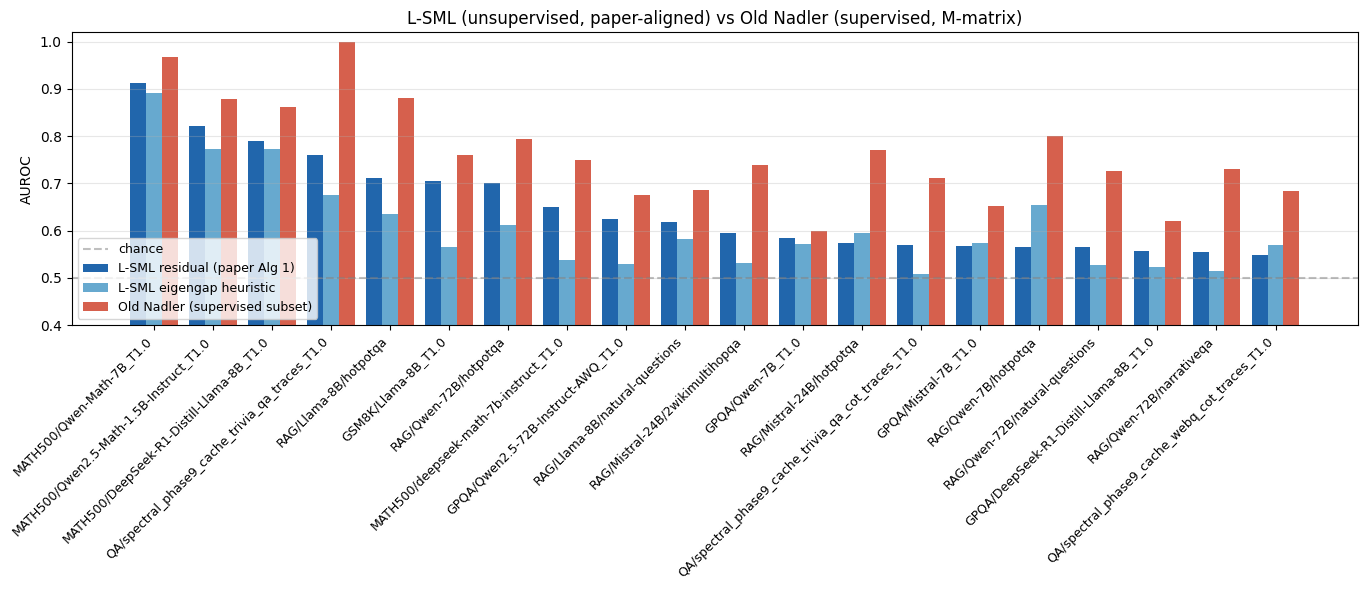

In [10]:
import matplotlib.pyplot as plt

# Bar comparison: L-SML residual vs L-SML eigengap vs old Nadler per domain
plot_df = summary_df.dropna(subset=['old_nadler_auc']).copy() if 'old_nadler_auc' in summary_df else summary_df.copy()
plot_df = plot_df.head(20)  # top 20 by L-SML residual AUROC

if len(plot_df) > 0:
    fig, ax = plt.subplots(figsize=(max(10, 0.5 * len(plot_df) + 4), 6))
    x = np.arange(len(plot_df))
    width = 0.27
    ax.bar(x - width, plot_df['lsml_resid_auc'], width,
           label='L-SML residual (paper Alg 1)', color='#2166ac')
    ax.bar(x,         plot_df['lsml_eig_auc'],   width,
           label='L-SML eigengap heuristic',     color='#67a9cf')
    if 'old_nadler_auc' in plot_df.columns and plot_df['old_nadler_auc'].notna().any():
        ax.bar(x + width, plot_df['old_nadler_auc'], width,
               label='Old Nadler (supervised subset)', color='#d6604d')
    ax.axhline(0.5, color='grey', linestyle='--', alpha=0.5, label='chance')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['domain_model'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('AUROC')
    ax.set_title('L-SML (unsupervised, paper-aligned) vs Old Nadler (supervised, M-matrix)')
    ax.legend(loc='lower left', fontsize=9)
    ax.set_ylim(0.4, 1.02)
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    p = os.path.join(LSML_PLOT_DIR, 'lsml_vs_nadler_comparison.png')
    fig.savefig(p, dpi=140)
    print(f'Saved {p}')
    plt.show()
else:
    print('No L-SML results to plot.')


## Done

**Saved files:**
- `consolidated_results/lsml_math500_res.pkl`
- `consolidated_results/lsml_gsm8k_res.pkl`
- `consolidated_results/lsml_gpqa_res.pkl`
- `consolidated_results/lsml_rag_res.pkl`
- `consolidated_results/lsml_qa_res.pkl`
- `consolidated_results/lsml_results_all.pkl` — combined
- `consolidated_results/lsml_summary.csv` — comparison table
- `consolidated_results/plots/lsml/lsml_vs_nadler_comparison.png`

**The original `results_all.pkl` and `results_summary.csv` from Step 100 are untouched.**

Each per-key L-SML result dict contains:
- `lsml_residual_auc`, `lsml_residual_lo/hi`, `lsml_residual_K` — paper-faithful headline
- `lsml_residual_c` (group assignment), `lsml_residual_groups` (per-group SML weights)
- `lsml_residual_cross_w` (cross-group SML weights)
- `lsml_eigengap_auc`, `lsml_eigengap_K`, `lsml_eigengap_c` — fast-heuristic comparison
- `group_ARI`, `same_K` — agreement between K-selection methods
- `ind_aucs` — individual feature AUROCs (unchanged from old method)
- `n`, `n_pos`, `n_neg` — sample counts
